In [1]:

"""
Train XGBoost model using spatial splits and sklearn-compatible pipeline.
Produces:
    - nested cross-validation metrics
    - out-of-fold predictions
    - calibration diagnostics
"""

"""
=================================
==  Primary reporting metrics  ==
=================================
OOF AUCPR — primary ranking metric

OOF Brier score — calibration/probability accuracy
OOF ECE — calibration summary
calibration plot — visual calibration check

OOF log loss — overall probabilistic performance
"""
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime
import json
import os
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# define project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

# Use data loading helpers
from src.data.data_loading import load_full_training_pool
from src.data.data_loading import load_test_data
from src.data.data_loading import get_cv_splits

# Use feature handling helpers
from src.data.feature_handling import get_feature_columns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier

from config.paths import MODEL_RUNS_DIR
from config.paths import RESULTS_DIR
from config.feature_groups import TARGET_COLUMN


RADON_HIGH_CONCENTRATION = 200
INNER_CV_STRATIFY_COLUMN = "provinceterritory"
INNER_CV_GROUP_COLUMN = "spatial_cluster"
OUTER_FOLD_COLUMN = "cv_fold"
TEST_COLUMN = "is_test"

RANDOM_STATE = 42


In [2]:
# ------------------------------------------------------------
# Run identity
# ------------------------------------------------------------
MODEL_NAME = "xgboost"   # change to: "random_forest" or "xgboost"

# nickname for run
BATCH_TAG = "overnight_2026_03_20"

SEARCH_SCORING = "neg_log_loss"
N_INNER_SPLITS = 3
N_RANDOM_SEARCH_ITERATIONS = 100


SAFE_SCORING_NAME = str(SEARCH_SCORING).replace("/", "_").replace(" ", "_")
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ID = f"{MODEL_NAME}_{BATCH_TAG}_{SAFE_SCORING_NAME}_{RUN_TIMESTAMP}"

RUN_DIR = MODEL_RUNS_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("MODEL_NAME:", MODEL_NAME)
print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)

MODEL_NAME: xgboost
RUN_ID: xgboost_overnight_2026_03_20_neg_log_loss_20260320_035024
RUN_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\xgboost_overnight_2026_03_20_neg_log_loss_20260320_035024


In [3]:
# Load the data 

# Assume that the split data is already created
# Use helper functions to load the data

train_df = load_full_training_pool().reset_index(drop=True)
# test_df  = load_test_data()

In [4]:
# HELPER FUNCTIONS 

# Build INNER SPLITS
# These inner splits are:
#   - stratified by province
#   - grouped by spatial_cluster
#
# IMPORTANT:
# The returned indices refer to the rows of X_subset passed here.

def make_inner_cv_splits(
    X_subset: pd.DataFrame,
    stratification_column: pd.Series,
    group_column: pd.Series,
    n_splits: int = N_INNER_SPLITS,
    random_state: int = RANDOM_STATE,
):
    inner_splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    inner_splits = list(
        inner_splitter.split(
            X=X_subset,
            y=stratification_column,
            groups=group_column,
        )
    )

    return inner_splits

# Compute calibration metric
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Compute Expected Calibration Error (ECE) for binary probabilities.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bin_edges[1:-1], right=True)

    ece = 0.0

    for bin_index in range(n_bins):
        in_bin = bin_ids == bin_index
        bin_count = np.sum(in_bin)

        if bin_count > 0:
            bin_accuracy = np.mean(y_true[in_bin])
            bin_confidence = np.mean(y_prob[in_bin])
            ece += (bin_count / len(y_true)) * abs(bin_accuracy - bin_confidence)

    return ece

In [5]:
# ------------------------------------------------------------
# Define Features and Target
# ------------------------------------------------------------

# Build feature list from config file + helper functions
# *** Do this in the pipeline preprocessor !!! ***
feature_columns = get_feature_columns(
    train_df,
    optional_excludes=None,   # standardized optional exclusion set
    extra_drop=None  # experiment-specific drops
)

# Create target
y_train_full = (train_df[TARGET_COLUMN] > RADON_HIGH_CONCENTRATION).astype(int)


# skip test data for now...
#X_test = test_df[feature_columns]
#y_test = test_df[target_column]

In [6]:
# ------------------------------------------------------------
# Use a helper function to get split data indices that work with sklearn's cross_validate()
cv_split_idx = get_cv_splits(train_df)
# then, cross_validate(pipe, X, y, cv=cv_split_idx)


In [7]:

# ------------------------------------------------------------
# Build Pipeline
# ------------------------------------------------------------
# XGBoost is tree-based, so scaling is not needed.
# We keep a median imputer so the sklearn pipeline structure stays
# close to the logistic-regression notebook.

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, feature_columns),
    ],
    remainder="drop",
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)


In [8]:

# ============================================================
# HYPERPARAMETER SEARCH SPACE
# ============================================================

positive_rate = y_train_full.mean()
negative_rate = 1.0 - positive_rate
approx_scale_pos_weight = negative_rate / positive_rate

print("Positive prevalence:", positive_rate)
print("Approximate neg/pos ratio:", approx_scale_pos_weight)

hyperparam_distributions = {
    "classifier__n_estimators": randint(150, 700),
    "classifier__max_depth": randint(3, 8),
    "classifier__learning_rate": loguniform(0.01, 0.2),
    "classifier__subsample": uniform(0.6, 0.4),          # 0.6 to 1.0
    "classifier__colsample_bytree": uniform(0.5, 0.5),   # 0.5 to 1.0
    "classifier__min_child_weight": randint(1, 12),
    "classifier__gamma": uniform(0.0, 2.0),
    "classifier__reg_alpha": loguniform(1e-4, 10.0),
    "classifier__reg_lambda": loguniform(1e-3, 100.0),
    "classifier__scale_pos_weight": [1.0, 2.0, 4.0, approx_scale_pos_weight],
}


Positive prevalence: 0.10859382468215276
Approximate neg/pos ratio: 8.20862676056338


In [9]:
print("train_df shape:", train_df.shape)
print("TARGET_COLUMN:", TARGET_COLUMN)
print("OUTER_FOLD_COLUMN:", OUTER_FOLD_COLUMN)

print("\nColumns in train_df:")
print(train_df.columns.tolist())

print("\ncv_fold counts:")
print(train_df[OUTER_FOLD_COLUMN].value_counts(dropna=False).sort_index())

outer_folds = sorted(train_df[OUTER_FOLD_COLUMN].dropna().unique())
print("\nouter_folds:", outer_folds)
print("number of outer folds:", len(outer_folds))

train_df shape: (10461, 80)
TARGET_COLUMN: concentration
OUTER_FOLD_COLUMN: cv_fold

Columns in train_df:
['FSA', 'n_days', 'concentration', 'longitude', 'latitude', 'hous_frac_type_single_detached', 'hous_frac_type_highrise', 'hous_frac_type_other_attached', 'hous_frac_type_movable', 'hous_avg_rooms', 'hous_frac_major_repair', 'hous_frac_age_pre_1980', 'hous_frac_age_1981_2000', 'hous_frac_age_post_2001', 'hous_median_value', 'demogr_pop_2016', 'demogr_num_total_dwellings', 'demogr_num_occ_dwellings', 'demogr_median_age', 'demogr_avg_household_size', 'demogr_frac_tenure_owned', 'demogr_frac_tenure_rented', 'demogr_frac_tenure_band', 'socioeco_frac_low_income', 'socioeco_median_income', 'socioeco_frac_high_income', 'socioeco_frac_govt_transfers', 'socioeco_frac_unemployment_rate', 'socioeco_frac_nonlaborer', 'socioeco_frac_bachelor_plus', 'socioeco_frac_overcrowded', 'socioeco_frac_unsuitable_housing', 'socioeco_frac_housing_burden', 'rxtp_intrusive_rocks', 'rxtp_metamorphic_rocks', 'r

In [10]:
# ============================================================
# NESTED CV FOLD
#    Added:
#   - fold-level metrics
#   - OOF probabilities
#   - ROC / PR / calibration artifacts
# ------------------------------------------------------------

CLASSIFICATION_THRESHOLD = 0.1
N_CALIBRATION_BINS = 10

oof_prob = np.full(len(train_df), np.nan)

outer_fold_results = []
roc_curves = []
pr_curves = []

outer_folds = sorted(train_df[OUTER_FOLD_COLUMN].dropna().unique())

print("About to start nested CV")
print("outer_folds:", outer_folds)
print("number of train rows:", len(train_df))

for outer_fold in outer_folds:

    print("\n" + "=" * 60)
    print(f"OUTER FOLD {outer_fold}")
    print("=" * 60)

    train_mask = train_df[OUTER_FOLD_COLUMN] != outer_fold
    val_mask = train_df[OUTER_FOLD_COLUMN] == outer_fold

    # Outer train
    X_tr = train_df.loc[train_mask, feature_columns].reset_index(drop=True)
    y_tr = y_train_full.loc[train_mask].reset_index(drop=True)

    # Outer validation
    X_val = train_df.loc[val_mask, feature_columns]
    y_val = y_train_full.loc[val_mask]

    # Inner fold metadata
    stratify_tr = train_df.loc[train_mask, INNER_CV_STRATIFY_COLUMN].reset_index(drop=True)
    groups_tr = train_df.loc[train_mask, INNER_CV_GROUP_COLUMN].reset_index(drop=True)

    inner_cv_splits = make_inner_cv_splits(
        X_subset=X_tr,
        stratification_column=stratify_tr,
        group_column=groups_tr,
        n_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
    )

    print("Outer-train rows:", len(X_tr))
    print("Outer-validation rows:", len(X_val))
    print("Number of inner splits:", len(inner_cv_splits))
    print("Outer-train positive rate:", y_tr.mean())
    print("Outer-validation positive rate:", y_val.mean())

    random_search = RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=hyperparam_distributions,
        n_iter=N_RANDOM_SEARCH_ITERATIONS,
        cv=inner_cv_splits,
        scoring=SEARCH_SCORING,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1,
    )

    random_search.fit(X_tr, y_tr)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_inner_score = random_search.best_score_

    print("Best params:", best_params)
    print("Best inner mean search score:", best_inner_score)

    y_val_prob = best_model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_prob >= CLASSIFICATION_THRESHOLD).astype(int)

    oof_prob[np.where(val_mask)[0]] = y_val_prob

    fold_roc_auc = roc_auc_score(y_val, y_val_prob)
    fold_aucpr = average_precision_score(y_val, y_val_prob)
    fold_logloss = log_loss(y_val, y_val_prob)
    fold_brier = brier_score_loss(y_val, y_val_prob)
    fold_ece = expected_calibration_error(y_val, y_val_prob, n_bins=N_CALIBRATION_BINS)
    fold_accuracy = accuracy_score(y_val, y_val_pred)
    fold_recall = recall_score(y_val, y_val_pred, zero_division=0)
    fold_f1 = f1_score(y_val, y_val_pred, zero_division=0)

    fold_fpr, fold_tpr, _ = roc_curve(y_val, y_val_prob)
    roc_curves.append((fold_fpr, fold_tpr))

    fold_precision, fold_recall_curve, _ = precision_recall_curve(y_val, y_val_prob)
    pr_curves.append((fold_recall_curve, fold_precision))

    fold_result = {
        "model_name": MODEL_NAME,
        "run_id": RUN_ID,
        "outer_fold": int(outer_fold),
        "n_train": int(len(X_tr)),
        "n_val": int(len(X_val)),
        "train_positive_rate": float(y_tr.mean()),
        "val_positive_rate": float(y_val.mean()),
        "roc_auc": float(fold_roc_auc),
        "aucpr": float(fold_aucpr),
        "log_loss": float(fold_logloss),
        "brier": float(fold_brier),
        "ece": float(fold_ece),
        "accuracy": float(fold_accuracy),
        "recall": float(fold_recall),
        "f1": float(fold_f1),
        "best_params_json": json.dumps(best_params, sort_keys=True, default=str),
    }

    outer_fold_results.append(fold_result)

    print(
        f"Fold {outer_fold} | "
        f"ROC-AUC: {fold_roc_auc:.4f} | "
        f"AUCPR: {fold_aucpr:.4f} | "
        f"LogLoss: {fold_logloss:.4f} | "
        f"Brier: {fold_brier:.4f} | "
        f"ECE: {fold_ece:.4f} | "
        f"Accuracy: {fold_accuracy:.4f} | "
        f"Recall: {fold_recall:.4f} | "
        f"F1: {fold_f1:.4f}",
        flush=True,
    )

    outer_fold_results_df = pd.DataFrame(outer_fold_results)
    outer_fold_results_df.to_csv(RUN_DIR / "outer_fold_results.csv", index=False)

print("\n" + "=" * 60)
print("FOLD-LEVEL RESULTS")
print("=" * 60)
display(outer_fold_results_df)


About to start nested CV
outer_folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
number of train rows: 10461

OUTER FOLD 0
Outer-train rows: 8392
Outer-validation rows: 2069
Number of inner splits: 3
Outer-train positive rate: 0.1124880838894185
Outer-validation positive rate: 0.09279845335911067
Fitting 3 folds for each of 100 candidates, totalling 300 fits


Best params: {'classifier__colsample_bytree': np.float64(0.7178364493389455), 'classifier__gamma': np.float64(1.460078633123637), 'classifier__learning_rate': np.float64(0.01153666052581368), 'classifier__max_depth': 4, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 235, 'classifier__reg_alpha': np.float64(0.00011802321563258201), 'classifier__reg_lambda': np.float64(0.0038050748350588197), 'classifier__scale_pos_weight': 1.0, 'classifier__subsample': np.float64(0.637662795307424)}
Best inner mean search score: -0.337047901172639
Fold 0 | ROC-AUC: 0.6307 | AUCPR: 0.1506 | LogLoss: 0.3010 | Brier: 0.0830 | ECE: 0.0123 | Accuracy: 0.5848 | Recall: 0.6042 | F1: 0.2126



OUTER FOLD 1
Outer-train rows: 8326
Outer-validation rows: 2135
Number of inner splits: 3
Outer-train positive rate: 0.1088157578669229
Outer-validation positive rate: 0.10772833723653395
Fitting 3 folds for each of 100 candidates, totalling 300 fits


Best params: {'classifier__colsample_bytree': np.float64(0.542418857042596), 'classifier__gamma': np.float64(1.973279157002351), 'classifier__learning_rate': np.float64(0.030685805769477312), 'classifier__max_depth': 3, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 649, 'classifier__reg_alpha': np.float64(0.001525548321519627), 'classifier__reg_lambda': np.float64(34.55162931337358), 'classifier__scale_pos_weight': 1.0, 'classifier__subsample': np.float64(0.9013512741035766)}
Best inner mean search score: -0.33516125106844497
Fold 1 | ROC-AUC: 0.6668 | AUCPR: 0.1993 | LogLoss: 0.3271 | Brier: 0.0931 | ECE: 0.0250 | Accuracy: 0.6066 | Recall: 0.5609 | F1: 0.2350



OUTER FOLD 2
Outer-train rows: 8345
Outer-validation rows: 2116
Number of inner splits: 3
Outer-train positive rate: 0.10161773517076093
Outer-validation positive rate: 0.13610586011342155
Fitting 3 folds for each of 100 candidates, totalling 300 fits


...

Best params: {'classifier__colsample_bytree': np.float64(0.7178364493389455), 'classifier__gamma': np.float64(1.460078633123637), 'classifier__learning_rate': np.float64(0.01153666052581368), 'classifier__max_depth': 4, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 235, 'classifier__reg_alpha': np.float64(0.00011802321563258201), 'classifier__reg_lambda': np.float64(0.0038050748350588197), 'classifier__scale_pos_weight': 1.0, 'classifier__subsample': np.float64(0.637662795307424)}
Best inner mean search score: -0.3191647881089393
Fold 3 | ROC-AUC: 0.6286 | AUCPR: 0.1868 | LogLoss: 0.3667 | Brier: 0.1076 | ECE: 0.0121 | Accuracy: 0.4400 | Recall: 0.7519 | F1: 0.2533



OUTER FOLD 4
Outer-train rows: 8363
Outer-validation rows: 2098
Number of inner splits: 3
Outer-train positive rate: 0.11574793734305872
Outer-validation positive rate: 0.08007626310772165
Fitting 3 folds for each of 100 candidates, totalling 300 fits


Best params: {'classifier__colsample_bytree': np.float64(0.5253842655196985), 'classifier__gamma': np.float64(1.7732342979013198), 'classifier__learning_rate': np.float64(0.010862511483797301), 'classifier__max_depth': 4, 'classifier__min_child_weight': 2, 'classifier__n_estimators': 200, 'classifier__reg_alpha': np.float64(0.021280904885895843), 'classifier__reg_lambda': np.float64(0.516681811478353), 'classifier__scale_pos_weight': 1.0, 'classifier__subsample': np.float64(0.9355734008277453)}
Best inner mean search score: -0.34738143212357825
Fold 4 | ROC-AUC: 0.6950 | AUCPR: 0.1661 | LogLoss: 0.2698 | Brier: 0.0720 | ECE: 0.0349 | Accuracy: 0.4285 | Recall: 0.8155 | F1: 0.1860



FOLD-LEVEL RESULTS


,model_name,run_id,outer_fold,n_train,n_val,train_positive_rate,val_positive_rate,roc_auc,aucpr,log_loss,brier,ece,accuracy,recall,f1,best_params_json
0,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,0,8392,2069,0.112488,0.092798,0.630679,0.150602,0.301043,0.082986,0.012293,0.584824,0.604167,0.212649,"{""classifier__colsample_bytree"": 0.71783644933..."
1,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,1,8326,2135,0.108816,0.107728,0.666849,0.199312,0.327080,0.093083,0.025016,0.606557,0.560870,0.234973,"{""classifier__colsample_bytree"": 0.54241885704..."
2,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,2,8345,2116,0.101618,0.136106,0.667906,0.232421,0.385066,0.114704,0.035947,0.636578,0.611111,0.314005,"{""classifier__colsample_bytree"": 0.71783644933..."
3,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,3,8418,2043,0.104300,0.126285,0.628594,0.186769,0.366713,0.107592,0.012102,0.440039,0.751938,0.253264,"{""classifier__colsample_bytree"": 0.71783644933..."
4,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,4,8363,2098,0.115748,0.080076,0.694967,0.166079,0.269811,0.072007,0.034905,0.428503,0.815476,0.186015,"{""classifier__colsample_bytree"": 0.52538426551..."


In [11]:
oof_predictions_df = pd.DataFrame({
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "row_index": train_df.index,
    "cv_fold": train_df[OUTER_FOLD_COLUMN].values,
    "y_true": y_train_full.values,
    "oof_prob": oof_prob,
    "oof_pred_at_threshold": (oof_prob >= CLASSIFICATION_THRESHOLD).astype(int),
})

for col in ["FSA", "province", TARGET_COLUMN]:
    if col in train_df.columns:
        oof_predictions_df[col] = train_df[col].values

oof_predictions_df.to_csv(RUN_DIR / "oof_predictions.csv", index=False)


In [12]:
print("Search scoring metric:", random_search.scoring)
print("Classification threshold:", CLASSIFICATION_THRESHOLD)
print("Max predicted probability in last outer fold:", y_val_prob.max())
print(f"Number >= {CLASSIFICATION_THRESHOLD}:", np.sum(y_val_prob >= CLASSIFICATION_THRESHOLD))
print("Quantiles:", np.quantile(y_val_prob, [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))


Search scoring metric: neg_log_loss
Classification threshold: 0.1
Max predicted probability in last outer fold: 0.2537268
Number >= 0.1: 1305
Quantiles: [0.04112329 0.08639802 0.11058622 0.13826612 0.17352366 0.20686562
 0.2446036  0.25372681]


In [13]:
# ------------------------------------------------------------
# Overall OOF metrics
# ------------------------------------------------------------

if np.any(np.isnan(oof_prob)):
    raise ValueError("Some OOF probabilities are still NaN.")

train_df = train_df.copy()
train_df["oof_prob"] = oof_prob
train_df["oof_pred_at_threshold"] = (train_df["oof_prob"] >= CLASSIFICATION_THRESHOLD).astype(int)

oof_roc_auc = roc_auc_score(y_train_full, train_df["oof_prob"])
oof_aucpr = average_precision_score(y_train_full, train_df["oof_prob"])
oof_logloss = log_loss(y_train_full, train_df["oof_prob"])
oof_brier = brier_score_loss(y_train_full, train_df["oof_prob"])
oof_ece = expected_calibration_error(y_train_full, train_df["oof_prob"], n_bins=N_CALIBRATION_BINS)

oof_accuracy = accuracy_score(y_train_full, train_df["oof_pred_at_threshold"])
oof_recall = recall_score(y_train_full, train_df["oof_pred_at_threshold"], zero_division=0)
oof_f1 = f1_score(y_train_full, train_df["oof_pred_at_threshold"], zero_division=0)

print("\n" + "=" * 60)
print("OVERALL OOF METRICS")
print("=" * 60)
print("Positive prevalence:", y_train_full.mean())
print("OOF ROC-AUC:", oof_roc_auc)
print("OOF AUCPR:", oof_aucpr)
print("OOF LogLoss:", oof_logloss)
print("OOF Brier:", oof_brier)
print("OOF ECE:", oof_ece)
print("OOF Accuracy:", oof_accuracy)
print("OOF Recall:", oof_recall)
print("OOF F1:", oof_f1)



OVERALL OOF METRICS
Positive prevalence: 0.10859382468215276
OOF ROC-AUC: 0.6480990163501115
OOF AUCPR: 0.18163856639797485
OOF LogLoss: 0.32991428826616626
OOF Brier: 0.09406610561760834
OOF ECE: 0.006074127803299596
OOF Accuracy: 0.5401013287448618
OOF Recall: 0.6619718309859155
OOF F1: 0.2381631037212985


In [14]:
thresholds_to_check = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

for threshold in thresholds_to_check:
    oof_pred = (train_df["oof_prob"] >= threshold).astype(int)

    threshold_accuracy = accuracy_score(y_train_full, oof_pred)
    threshold_recall = recall_score(y_train_full, oof_pred, zero_division=0)
    threshold_f1 = f1_score(y_train_full, oof_pred, zero_division=0)

    print(
        f"Threshold {threshold:.2f} | "
        f"Accuracy: {threshold_accuracy:.4f} | "
        f"Recall: {threshold_recall:.4f} | "
        f"F1: {threshold_f1:.4f} | "
        f"Predicted positives: {oof_pred.sum()}"
    )

Threshold 0.05 | Accuracy: 0.2126 | Recall: 0.9710 | F1: 0.2112 | Predicted positives: 9307
Threshold 0.10 | Accuracy: 0.5401 | Recall: 0.6620 | F1: 0.2382 | Predicted positives: 5179
Threshold 0.15 | Accuracy: 0.7812 | Recall: 0.3820 | F1: 0.2749 | Predicted positives: 2021
Threshold 0.20 | Accuracy: 0.8519 | Recall: 0.1329 | F1: 0.1632 | Predicted positives: 715
Threshold 0.25 | Accuracy: 0.8816 | Recall: 0.0484 | F1: 0.0815 | Predicted positives: 213


Threshold 0.30 | Accuracy: 0.8863 | Recall: 0.0290 | F1: 0.0526 | Predicted positives: 119


In [15]:
# ------------------------------------------------------------
# Mean ± std across outer folds
# ------------------------------------------------------------

metric_columns = [
    "roc_auc",
    "aucpr",
    "log_loss",
    "brier",
    "ece",
    "accuracy",
    "recall",
    "f1",
]

print("\n" + "=" * 60)
print("MEAN PERFORMANCE ACROSS OUTER FOLDS")
print("=" * 60)

for metric_name in metric_columns:
    metric_mean = outer_fold_results_df[metric_name].mean()
    metric_std = outer_fold_results_df[metric_name].std()
    print(f"{metric_name}: {metric_mean:.4f} ± {metric_std:.4f}")



MEAN PERFORMANCE ACROSS OUTER FOLDS
roc_auc: 0.6578 ± 0.0281
aucpr: 0.1870 ± 0.0315
log_loss: 0.3299 ± 0.0470
brier: 0.0941 ± 0.0175
ece: 0.0241 ± 0.0116
accuracy: 0.5393 ± 0.0977
recall: 0.6687 ± 0.1091
f1: 0.2402 ± 0.0483


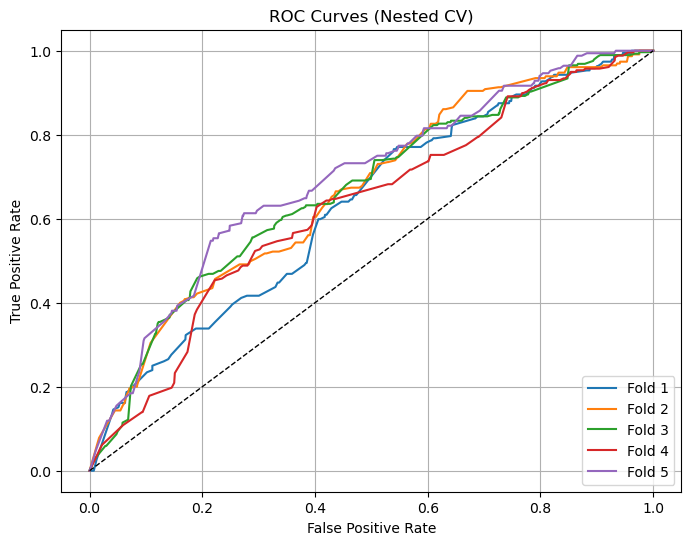

In [16]:
# ------------------------------------------------------------
# ROC curves for all outer folds
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for i, (fpr, tpr) in enumerate(roc_curves, start=1):
    plt.plot(fpr, tpr, label=f"Fold {i}")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Nested CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

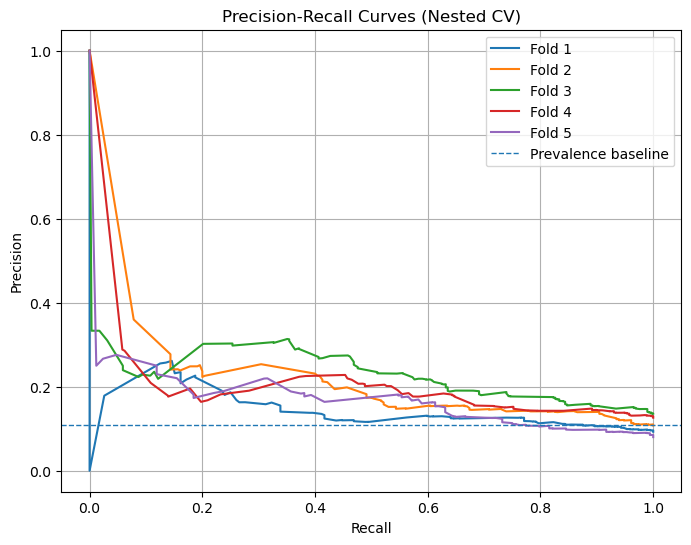

In [17]:
# ------------------------------------------------------------
# Precision-Recall curves for all outer folds
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for i, (recall_curve_values, precision_values) in enumerate(pr_curves, start=1):
    plt.plot(recall_curve_values, precision_values, label=f"Fold {i}")

baseline_prevalence = y_train_full.mean()
plt.axhline(y=baseline_prevalence, linestyle="--", linewidth=1, label="Prevalence baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Nested CV)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

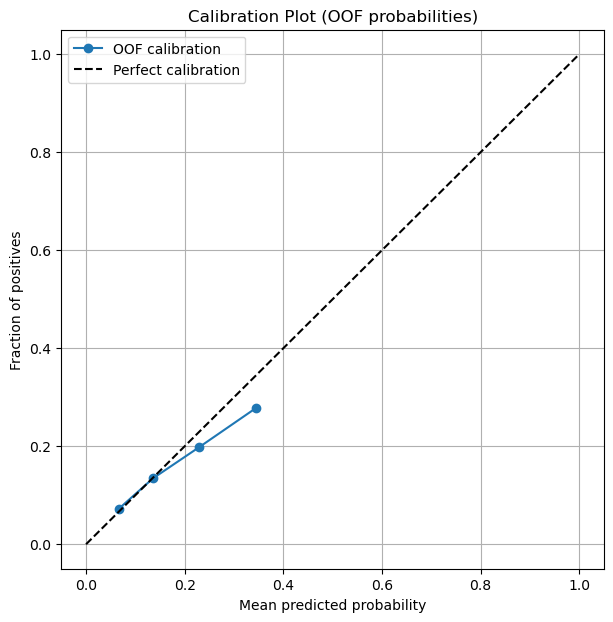

In [18]:
# ------------------------------------------------------------
# Calibration plot from OOF probabilities
# ------------------------------------------------------------

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_train_full,
    train_df["oof_prob"],
    n_bins=N_CALIBRATION_BINS,
    strategy="uniform",
)

plt.figure(figsize=(7, 7))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label="OOF calibration")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (OOF probabilities)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

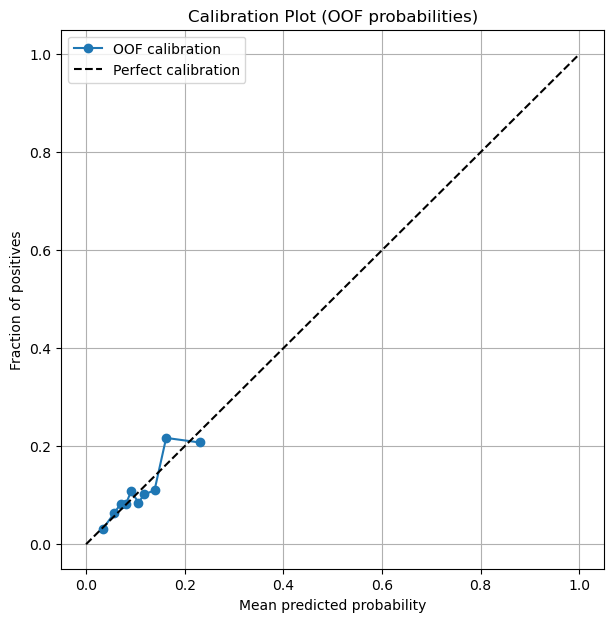

In [19]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_train_full,
    train_df["oof_prob"],
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 7))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label="OOF calibration")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (OOF probabilities)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [20]:
summary_results = {
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "batch_tag": BATCH_TAG,
    "search_scoring": SEARCH_SCORING,
    "n_rows": int(len(train_df)),
    "positive_rate": float(y_train_full.mean()),
    "n_outer_folds": int(train_df[OUTER_FOLD_COLUMN].nunique()),
    "classification_threshold": float(CLASSIFICATION_THRESHOLD),
    "n_calibration_bins": int(N_CALIBRATION_BINS),
    "oof_roc_auc": float(oof_roc_auc),
    "oof_aucpr": float(oof_aucpr),
    "oof_log_loss": float(oof_logloss),
    "oof_brier": float(oof_brier),
    "oof_ece": float(oof_ece),
    "oof_accuracy": float(oof_accuracy),
    "oof_recall": float(oof_recall),
    "oof_f1": float(oof_f1),
    "mean_fold_roc_auc": float(pd.DataFrame(outer_fold_results)["roc_auc"].mean()),
    "mean_fold_aucpr": float(pd.DataFrame(outer_fold_results)["aucpr"].mean()),
    "mean_fold_log_loss": float(pd.DataFrame(outer_fold_results)["log_loss"].mean()),
    "mean_fold_brier": float(pd.DataFrame(outer_fold_results)["brier"].mean()),
    "mean_fold_ece": float(pd.DataFrame(outer_fold_results)["ece"].mean()),
}

with open(RUN_DIR / "summary_metrics.json", "w") as f:
    json.dump(summary_results, f, indent=2)

pd.DataFrame([summary_results]).to_csv(RUN_DIR / "summary_metrics.csv", index=False)


In [21]:
# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

train_df.to_csv(RUN_DIR / "xgboost_oof_predictions_with_metadata.csv", index=False)
outer_fold_results_df.to_csv(RUN_DIR / "xgboost_outer_fold_results.csv", index=False)

summary_results_xgb = {
    "run_id": RUN_ID,
    "run_timestamp": RUN_TIMESTAMP,
    "search_scoring": SEARCH_SCORING,
    "n_random_search_iterations": N_RANDOM_SEARCH_ITERATIONS,
    "n_inner_splits": N_INNER_SPLITS,
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "n_calibration_bins": N_CALIBRATION_BINS,
    "oof_roc_auc": oof_roc_auc,
    "oof_aucpr": oof_aucpr,
    "oof_logloss": oof_logloss,
    "oof_brier": oof_brier,
    "oof_ece": oof_ece,
    "oof_accuracy": oof_accuracy,
    "oof_recall": oof_recall,
    "oof_f1": oof_f1,
    "prevalence": y_train_full.mean(),
    "n_train_rows": len(train_df),
}

summary_results_xgb_df = pd.DataFrame([summary_results_xgb])

summary_results_xgb_df.to_csv(
    RUN_DIR / "xgboost_summary_results.csv",
    index=False
)

display(summary_results_xgb_df)


,run_id,run_timestamp,search_scoring,n_random_search_iterations,n_inner_splits,classification_threshold,n_calibration_bins,oof_roc_auc,oof_aucpr,oof_logloss,oof_brier,oof_ece,oof_accuracy,oof_recall,oof_f1,prevalence,n_train_rows
0,xgboost_overnight_2026_03_20_neg_log_loss_2026...,20260320_035024,neg_log_loss,100,3,0.1,10,0.648099,0.181639,0.329914,0.094066,0.006074,0.540101,0.661972,0.238163,0.108594,10461


In [22]:
# ------------------------------------------------------------
# Optional: inspect feature importances from a final refit on all training data
# ------------------------------------------------------------
# This is NOT an unbiased performance estimate.
# It is just a model-interpretation step after your OOF evaluation.

final_xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=hyperparam_distributions,
    n_iter=N_RANDOM_SEARCH_ITERATIONS,
    cv=make_inner_cv_splits(
        X_subset=train_df[feature_columns].reset_index(drop=True),
        stratification_column=train_df[INNER_CV_STRATIFY_COLUMN].reset_index(drop=True),
        group_column=train_df[INNER_CV_GROUP_COLUMN].reset_index(drop=True),
        n_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
    ),
    scoring=SEARCH_SCORING,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

final_xgb_search.fit(train_df[feature_columns], y_train_full)

final_xgb_model = final_xgb_search.best_estimator_
final_xgb_classifier = final_xgb_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance": final_xgb_classifier.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importance_df.head(20))


Fitting 3 folds for each of 100 candidates, totalling 300 fits


,feature,importance
9,geolprov_interior_platform,0.037251
43,hous_frac_type_single_detached,0.032816
55,socioeco_frac_housing_burden,0.032469
25,sedi_eolian_sediments,0.030002
61,socioeco_median_income,0.029174
13,geolprov_st_lawrence_platform,0.028318
16,rxtp_intrusive_rocks,0.028138
40,hous_frac_major_repair,0.027433
42,hous_frac_type_other_attached,0.025096
17,rxtp_metamorphic_rocks,0.024601
